# Data Preprocessing

In [1]:
import pandas as pd

In [2]:
# Transform Generation Data
## Variables
gen_cols = {
    'Datum von': 'datetime',
    'Erdgas [MWh] Originalauflösungen': 'fossil_gas',
    'Braunkohle [MWh] Originalauflösungen': 'lignite',
    'Steinkohle [MWh] Originalauflösungen': 'hard_coal',
    'Sonstige Konventionelle [MWh] Originalauflösungen': 'other_conventionals'
}
emi_cols = {
    'Datetime': 'datetime',
    'Braunkohle': 'lignite',
    'Erdgas': 'fossil_gas',
    'Andere': 'other_conventionals',
    'Steinkohle': 'hard_coal',
    'Absolute Emissionen': 'total_emissions',
    'CO₂-Emissionsfaktor des Strommix': 'aef'
}

In [3]:
# Function to transform values to float and set index
import pytz

def rename_cols_and_make_float(df, col_names, is_iso, make_sum):
    # Rename columns that will be kept
    df = df.rename(columns=col_names)

    # Only keep columns from keep_cols
    df = df.loc[:, [c for c in df.columns if c in col_names.values()]]

    # Transform date columns to datetime and set index
    if not is_iso:
        df['datetime'] = pd.to_datetime(df['datetime'], format="%d.%m.%Y %H:%M")
    if is_iso:
        df['datetime'] = pd.to_datetime(df['datetime'], format="ISO8601")

    df = df.set_index('datetime')

    # Set timezone to UTC
    try:
        df.index = df.index.tz_localize('Europe/Berlin', ambiguous='infer')
    except pytz.exceptions.AmbiguousTimeError:
        df.index = df.index.tz_localize('Europe/Berlin', ambiguous=True)
        df.index = df.index.tz_convert('UTC')

    # Transform columns to numeric
    for col in df.columns:
        if not pd.api.types.is_float_dtype(df[col]):
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Round to 2 decimals
        df[col] = df[col].round(2)

    # Aggregate conventional generation
    if make_sum:
        df['total_generation'] = df.sum(axis=1, numeric_only=True)

    return df

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL

def _mad(x: pd.Series) -> float:
    """Median Absolute Deviation (robust scale)."""
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    m = x.median()
    return (x - m).abs().median()

def detect_outliers_mstl(df, col, z_thresh=6.0, periods=(96, 672), min_points=10_000):
    """
    Option 1: MSTL (Tag + Woche) + 'Jahreszeit'-Erweiterung über Monats-Level-Korrektur.
    Outlier-Kriterium: robuster Z-Score auf (resid - monthly_median(resid)) via MAD.

    Parameters
    ----------
    df : pd.DataFrame
        Muss einen DatetimeIndex haben (UTC ist ok) und 15-minütliche Daten enthalten/abbildbar sein.
    col : str
        Spalte, die geprüft werden soll.
    z_thresh : float
        Schwelle im robusten Z-Score (typisch 5-8). Höher = weniger Outlier.
    periods : tuple[int, int]
        (day, week) in 15-min steps: (96, 672).
    min_points : int
        Schutz: MSTL ist bei sehr kurzen Reihen unsauber; darunter wird abgebrochen.

    Returns
    -------
    anomalies : pd.DataFrame
        Zeilen der Outlier mit Zusatzinfos (value, expected, resid, resid_adj, z_robust).
    mstl_result : MSTLResult
        Statsmodels Result mit trend/seasonal/resid.
    """
    if col not in df.columns:
        raise KeyError(f"Spalte '{col}' nicht in df.")

    s = df[col].copy()

    # Index/Sortierung/Frequenz
    s = s.sort_index()
    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("df muss einen DatetimeIndex haben (DatetimeIndex).")

    s = s.asfreq("15min")
    if s.isna().any():
        # Zeitbasierte Interpolation ist für physikalische Reihen meist sinnvoll
        s = s.interpolate(method="time").dropna()

    if len(s) < min_points:
        raise ValueError(f"Zu wenig Datenpunkte für MSTL ({len(s)} < {min_points}).")

    # --- MSTL: Tag + Woche ---
    mstl = MSTL(s, periods=periods, stl_kwargs={'robust': True})
    res = mstl.fit()

    resid = res.resid

    # --- Jahreszeit-Erweiterung: Monats-Level aus den Residuen entfernen ---
    resid_month_med = resid.groupby(resid.index.month).transform("median")
    resid_adj = resid - resid_month_med

    # --- Robuster Z-Score via MAD ---
    scale = 1.4826 * _mad(resid_adj)
    if not np.isfinite(scale) or scale == 0:
        raise ValueError("Robuste Skala (MAD) ist 0/NaN; Residuen evtl. konstant oder fehlerhaft.")

    z = (resid_adj - resid_adj.median()) / scale

    # Outlier-DF
    mask = z.abs() > z_thresh

    # Calculate expected value robustly
    seasonal_sum = pd.DataFrame(res.seasonal).sum(axis=1)
    expected_values = res.trend + seasonal_sum

    anomalies = pd.DataFrame(
        {
            col: s,
            "expected": expected_values,
            "resid": resid,
            "resid_adj": resid_adj,
            "z_robust": z,
        },
        index=s.index,
    ).loc[mask].copy()

    # --- Plot: Serie + Outlier ---
    plt.figure(figsize=(15, 6))
    plt.plot(s.index, s.values, color="steelblue", alpha=0.45, linewidth=1.0, label="Original")
    plt.scatter(
        anomalies.index,
        anomalies[col].values,
        color="crimson",
        s=18,
        alpha=0.9,
        label=f"Outlier (n={len(anomalies)})",
        zorder=5,
    )
    plt.title(f"{col} – Outlier via MSTL(day={periods[0]}, week={periods[1]}) + Monats-Korrektur | z>{z_thresh}")
    plt.xlabel("Zeit")
    plt.ylabel(col)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optionaler Diagnostik-Plot: resid_adj und Schwelle
    plt.figure(figsize=(15, 4))
    plt.plot(resid_adj.index, resid_adj.values, color="gray", alpha=0.6, linewidth=0.8, label="Residuen (monatlich adjustiert)")
    thr = z_thresh * scale
    plt.axhline(+thr, color="crimson", linestyle="--", linewidth=1.0, label=f"±Schwelle (|resid_adj|>{thr:.2f})")
    plt.axhline(-thr, color="crimson", linestyle="--", linewidth=1.0)
    plt.title("Residuen nach MSTL + Monats-Level-Korrektur (Outlier-Schwelle)")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return anomalies, res

## (1) Generation Data

In [5]:
gen_dir = {
    'f_hertz': pd.read_csv(
        '../data/raw/smard/fileshare/market_data/Realisierte_Erzeugung_50Hertz_202212240000_202501010000_Viertelstunde.csv',
        sep=';'
    ),
    'amprion': pd.read_csv(
        '../data/raw/smard/fileshare/market_data/Realisierte_Erzeugung_Amprion_202212240000_202501010000_Viertelstunde.csv',
        sep=';'
    ),
    'tennet': pd.read_csv(
        '../data/raw/smard/fileshare/market_data/Realisierte_Erzeugung_TenneT_202212240000_202501010000_Viertelstunde.csv',
        sep=';'
    ),
    'transnet_bw': pd.read_csv(
        '../data/raw/smard/fileshare/market_data/Realisierte_Erzeugung_TransnetBW_202212240000_202501010000_Viertelstunde.csv',
        sep=';'
    )
}

for area, df in gen_dir.items():
    gen_dir[area] = rename_cols_and_make_float(df, gen_cols, is_iso=False, make_sum=True)

    print(f"### [{area.upper()}] ###")
    print(gen_dir[area].info())
    print("")
    print(gen_dir[area].describe())
    print("")

### [F_HERTZ] ###
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70944 entries, 2022-12-24 00:00:00+01:00 to 2024-12-31 23:45:00+01:00
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   lignite              70944 non-null  float64
 1   hard_coal            70944 non-null  float64
 2   fossil_gas           70944 non-null  float64
 3   other_conventionals  70943 non-null  float64
 4   total_generation     70944 non-null  float64
dtypes: float64(5)
memory usage: 3.2 MB
None

            lignite     hard_coal    fossil_gas  other_conventionals  \
count  70944.000000  70944.000000  70944.000000         70943.000000   
mean    1163.247121    116.998531    352.521609           190.064858   
std      469.454330     81.295695    201.069690            35.156753   
min      307.250000      7.750000     81.250000            81.500000   
25%      744.500000     56.000000    200.500000           179.500000   

/tmp/ipykernel_34505/1109024880.py:64: FutureWarning: The provided callable <function median at 0x7b8cb0102ac0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  resid_month_med = resid.groupby(resid.index.month).transform(np.median)


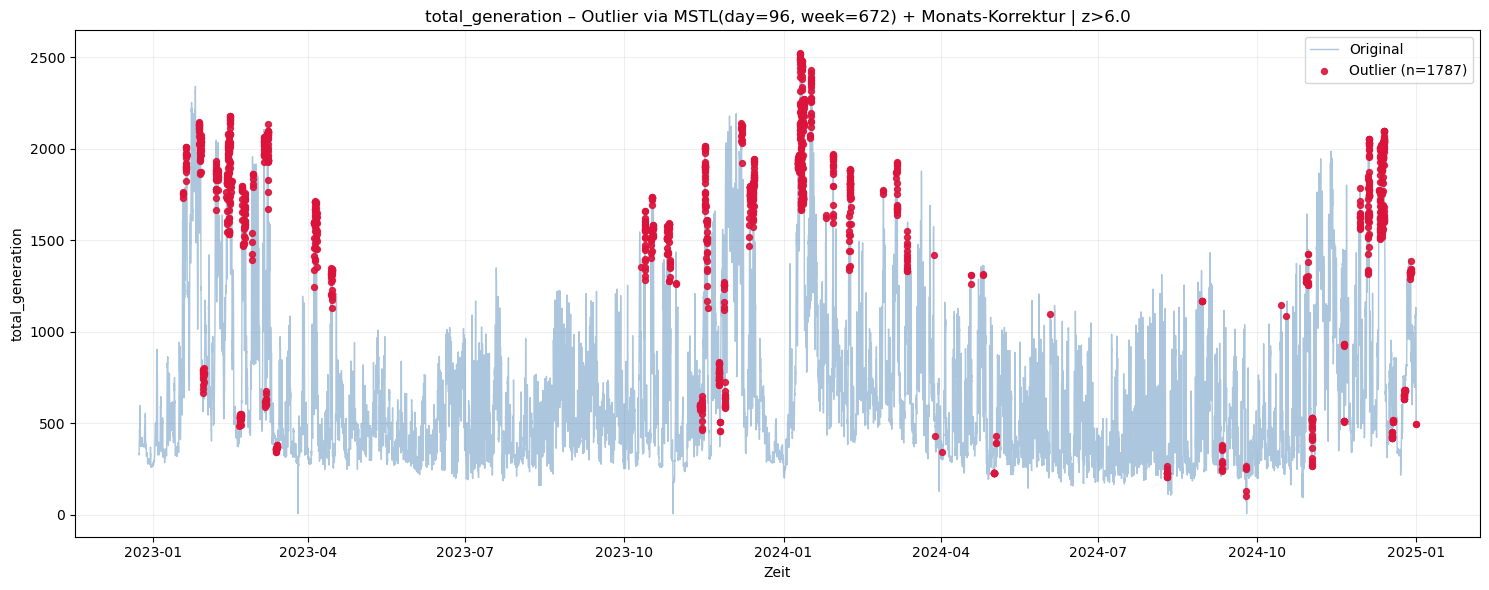

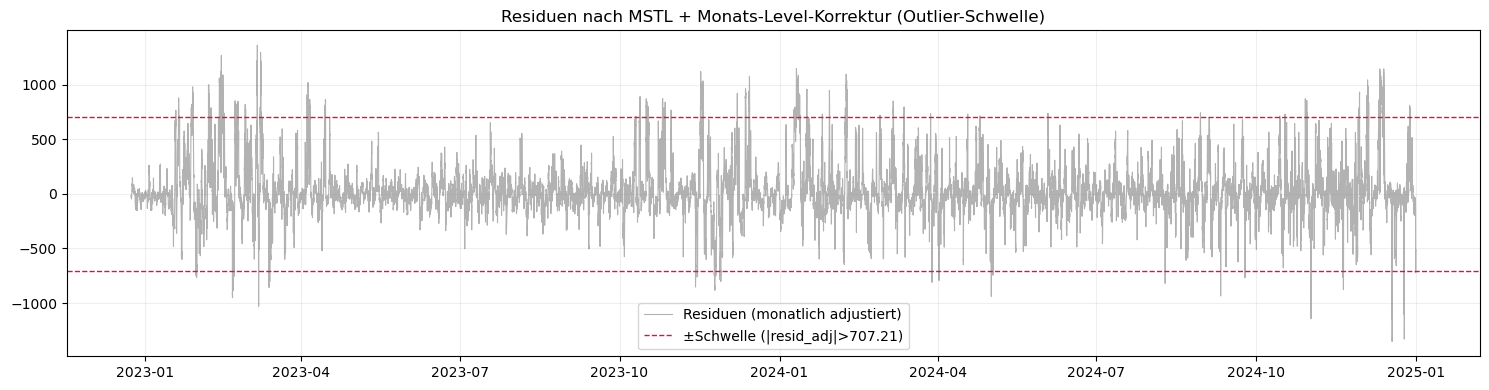

In [6]:
# Detect outliers
try:
    anomalies, mstl_res = detect_outliers_mstl(gen_dir['tennet'], "total_generation", z_thresh=6.0)
    anomalies.head()
except Exception as e:
    print(f"Error detecting outliers: {e}")

## (2) Emissions Data

In [7]:
emi_dir = {
    'first': pd.read_csv('../data/raw/agora/emissions_ger_2022_hourly_lastweek.csv', sep=','),
    'second': pd.read_csv('../data/raw/agora/emissions_ger_2023_hourly.csv', sep=','),
    'third': pd.read_csv('../data/raw/agora/emissions_ger_2024_hourly.csv', sep=',')
}

for year, df in emi_dir.items():
    emi_dir[year] = rename_cols_and_make_float(df, emi_cols, is_iso=True, make_sum=False)

    print(f"### [{year.upper()}] ###")
    print(df.info())
    print("")
    print(df.describe())
    print("")

### [FIRST] ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Datetime                          193 non-null    object 
 1   Andere                            193 non-null    float64
 2   Braunkohle                        193 non-null    float64
 3   Steinkohle                        193 non-null    float64
 4   Erdgas                            193 non-null    float64
 5   Absolute Emissionen               193 non-null    float64
 6   CO₂-Emissionsfaktor des Strommix  193 non-null    float64
dtypes: float64(6), object(1)
memory usage: 10.7+ KB
None

            Andere    Braunkohle   Steinkohle       Erdgas  \
count   193.000000    193.000000   193.000000   193.000000   
mean   2329.076073   6879.121461  2533.483451  2859.577813   
std     182.321454   2882.716170   703.881525   128.862056   
min   

Plotting features for first...


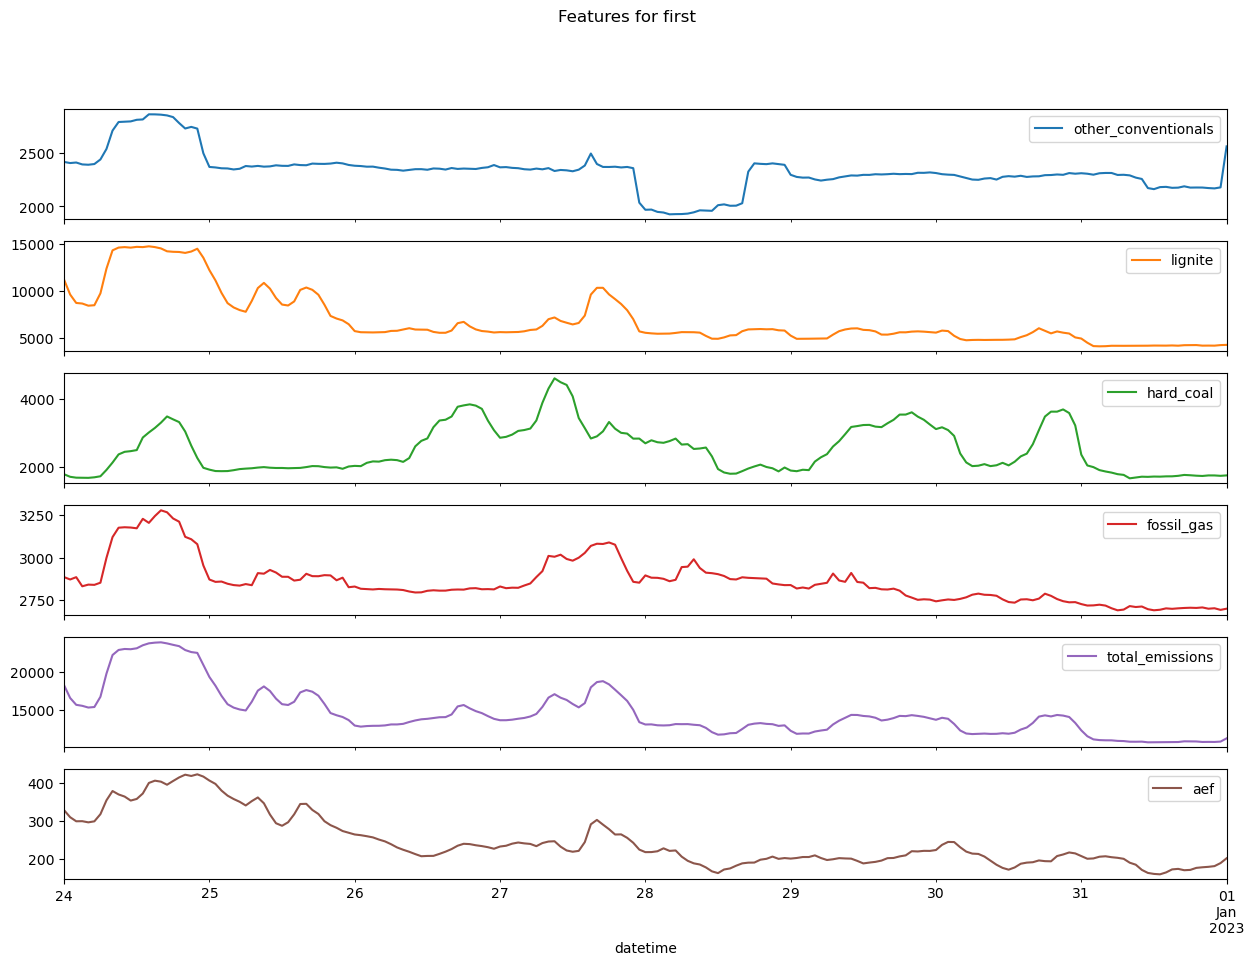

Plotting features for second...


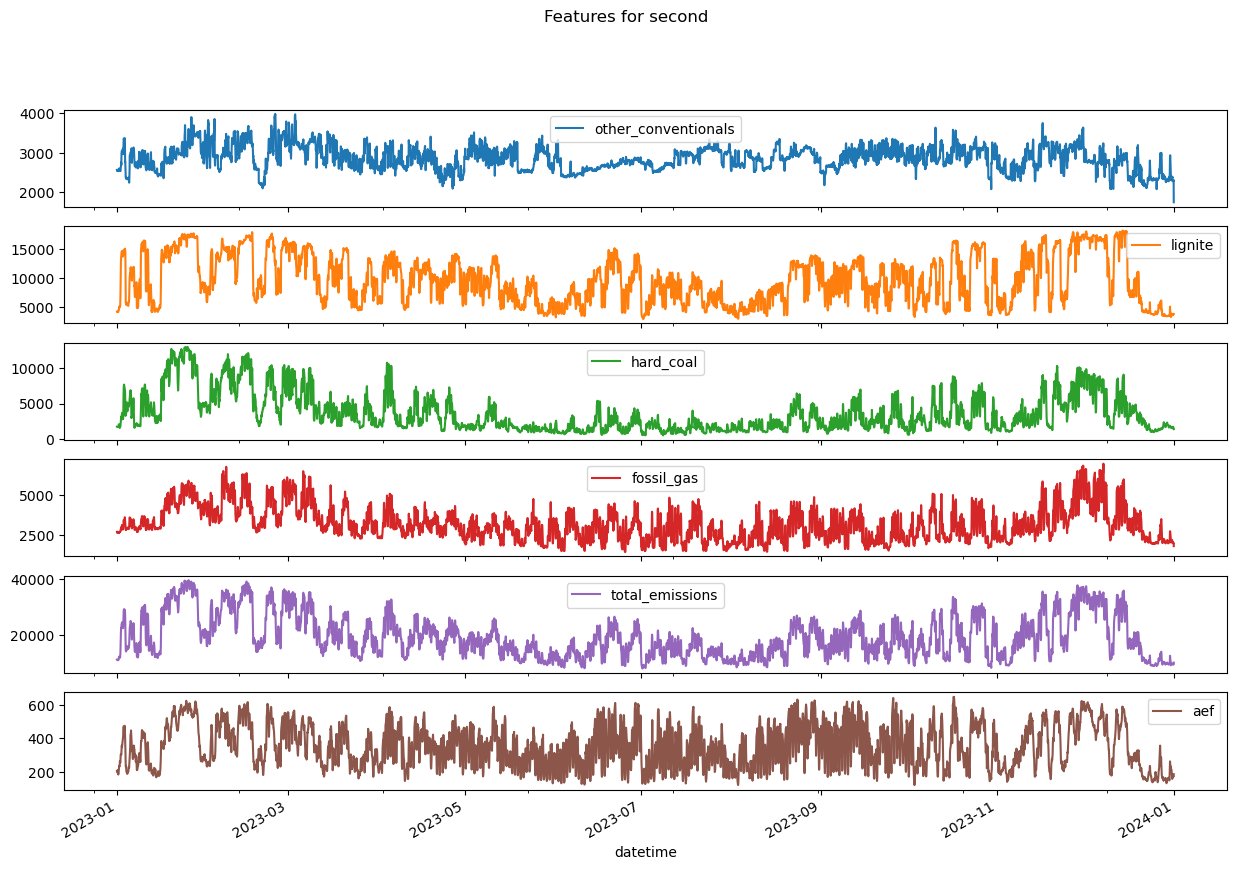

Plotting features for third...


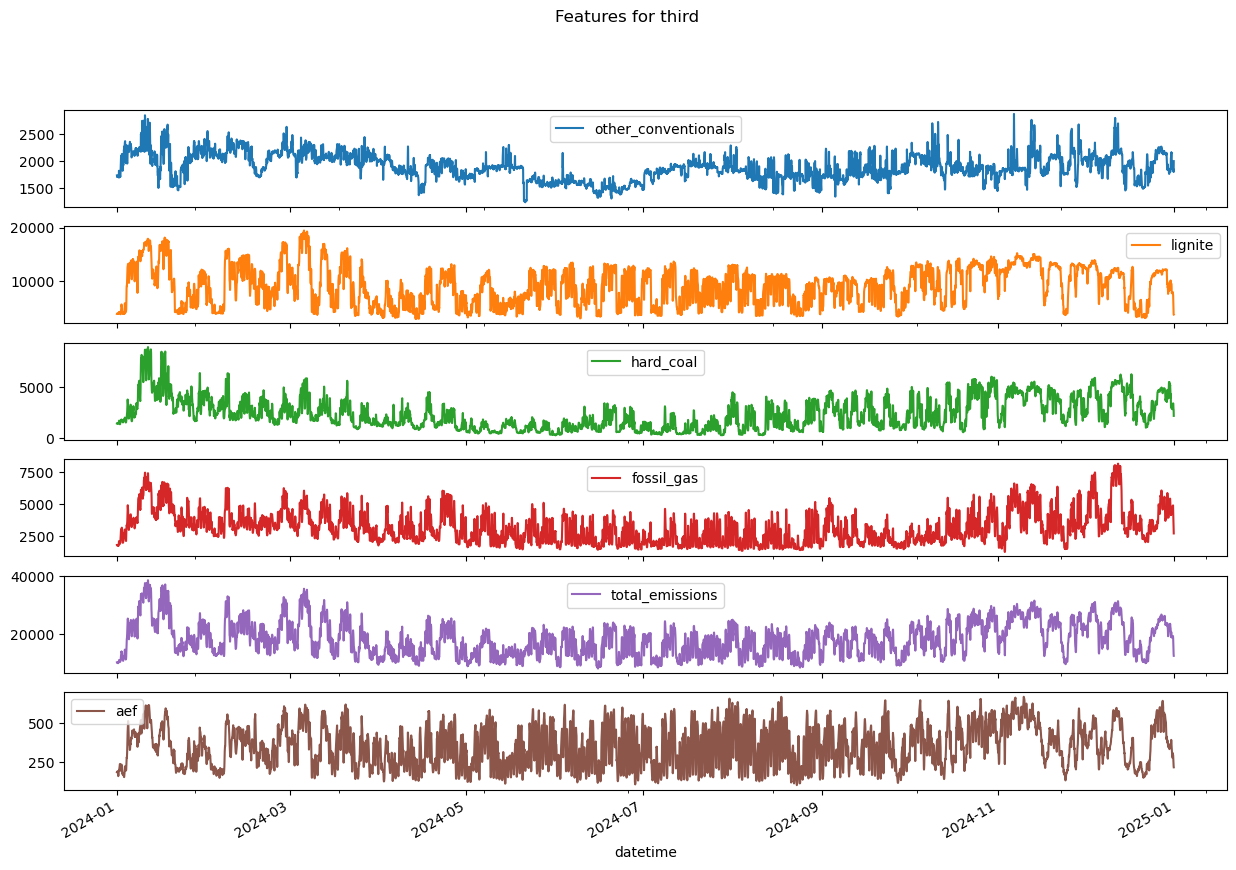

In [8]:
# Plot features for emissions data
for year, df in emi_dir.items():
    print(f"Plotting features for {year}...")
    df.plot(subplots=True, figsize=(15, 10), title=f"Features for {year}")
    plt.show()